Dataset Shape: (16969, 10)

First 5 Rows:
   Age  Blood Glucose Level(BGL)  Diastolic Blood Pressure  \
0    9                        79                        73   
1    9                        80                        73   
2    9                        70                        76   
3    9                        70                        78   
4   66                       100                        96   

   Systolic Blood Pressure  Heart Rate  Body Temperature  SPO2  \
0                      118          98         98.300707    99   
1                      119         102         98.300707    94   
2                      110          81         98.300707    98   
3                      115          96         98.300707    96   
4                      144          92         97.807052    98   

   Sweating  (Y/N)  Shivering (Y/N) Diabetic/NonDiabetic (D/N)  
0                0                0                          N  
1                1                0                       

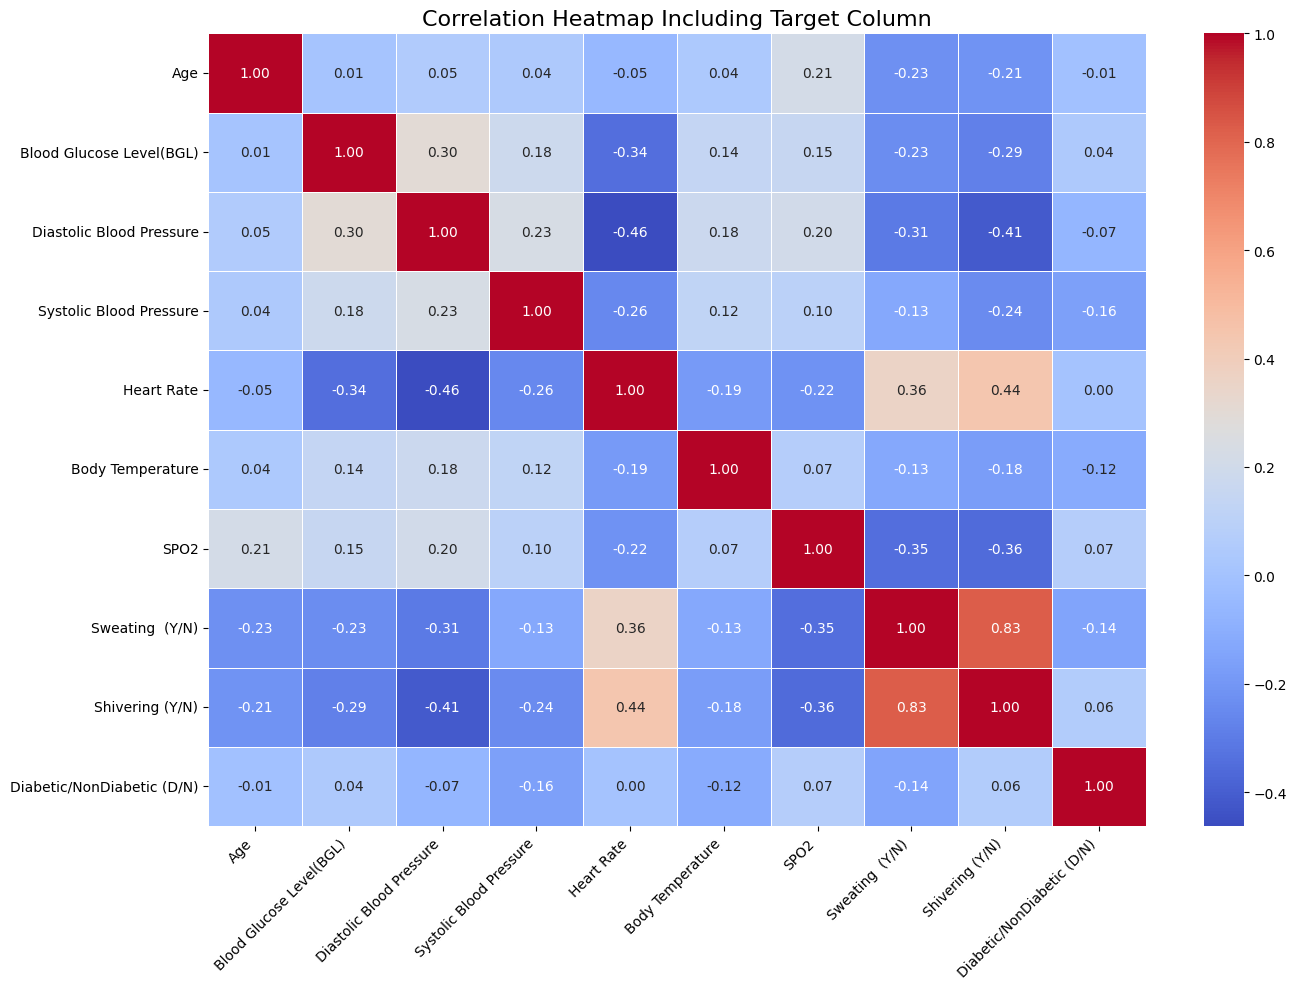

In [1]:
# ============================================================
# LOAD DATASET AND FULL HEATMAP INCLUDING TARGET COLUMN
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------
# 1. Load Excel dataset
# ------------------------------------------------------------

file_path = "Dataset for People for their Blood Glucose Level with their Superficial body feature readings.xlsx"

# Header starts from row 3, so use header=2
df = pd.read_excel(file_path, header=2)

# ------------------------------------------------------------
# 2. Basic dataset checking
# ------------------------------------------------------------

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# ------------------------------------------------------------
# 3. Clean column names
# ------------------------------------------------------------

df.columns = df.columns.str.strip()

print("\nCleaned Column Names:")
print(df.columns)

# ------------------------------------------------------------
# 4. Encode target column
# ------------------------------------------------------------

target_col = "Diabetic/NonDiabetic (D/N)"

# Convert D and N into numbers
df[target_col] = df[target_col].map({
    "D": 1,
    "N": 0
})

print("\nTarget Column Value Counts:")
print(df[target_col].value_counts())

# ------------------------------------------------------------
# 5. Encode any remaining categorical columns
# ------------------------------------------------------------

label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = label_encoder.fit_transform(df[col].astype(str))

# ------------------------------------------------------------
# 6. Correlation matrix
# ------------------------------------------------------------

correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation with Target Column:")
print(correlation_matrix[target_col].sort_values(ascending=False))

# ------------------------------------------------------------
# 7. Full heatmap including target column
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap Including Target Column", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()